# derived_8.4-eval-1.2 — Leave-One-Station-Out (LOSO) Spatial Generalization

This experiment evaluates **spatial generalization** of every model configuration from `derived_8.4-eval-1.1` (2 baselines + 5 MoE routing strategies × 9 per-regime delta-grid points = 47 configurations, all sharing the same 54-feature backbone / V0-50 features / hyperparameters) under a **leave-one-station-out** (LOSO) protocol on the 7 Washington stations of the `derived_8.4` split.

For each configuration and each held-out station $s$: the router is refitted and experts are trained on the trainval rows of the **remaining 6 stations** (train 2017–2020 + val 2021–2022), then evaluated on all test rows of station $s$ (2023–2025). Per-configuration × per-station metrics are collected, so station difficulty is a direct byproduct.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
from IPython.display import Image, display

EXP_DIR = Path(".")
df_summary = pd.read_csv(EXP_DIR / "loso_config_summary.csv")
df_station = pd.read_csv(EXP_DIR / "loso_station_summary.csv")
df_pcs = pd.read_csv(EXP_DIR / "loso_per_config_station.csv")
df_regime = pd.read_csv(EXP_DIR / "loso_per_regime_metrics.csv")
df_year = pd.read_csv(EXP_DIR / "loso_per_year_metrics.csv")

print(f"Loaded {len(df_summary)} configurations, {len(df_station)} stations, "
      f"{len(df_pcs)} config×station folds, {len(df_regime)} regime rows, {len(df_year)} year rows.")

Loaded 47 configurations, 7 stations, 329 config×station folds, 644 regime rows, 987 year rows.


## LOSO Configuration Leaderboard

Mean $R^2$ across the 7 held-out stations (each model trained on the other 6 stations, tested on the held-out one). `loso_mean_r2` is the average of per-station $R^2$; `loso_pooled_r2` is the sample-count-weighted $R^2$ over the concatenated 6,620 held-out test samples (directly comparable to eval-1.1's pooled test $R^2$); `loso_min/max_r2` show the spread across stations. `eval11_test_r2` is the same configuration's *temporal* test $R^2$ from `derived_8.4-eval-1.1`; `loso_minus_test_r2` is the spatial-generalization gap (mean-of-stations version).


In [2]:
leaderboard_cols = [
    "config_label", "strategy_name", "loso_mean_r2", "loso_pooled_r2", "loso_std_r2",
    "loso_min_r2", "loso_max_r2", "loso_mean_rmse", "loso_mean_bias", "eval11_test_r2",
    "loso_minus_test_r2", "is_winner",
]
print("### LOSO Configuration Leaderboard (mean R² over 7 held-out stations)")
print(df_summary[leaderboard_cols].to_markdown(index=False))


### LOSO Configuration Leaderboard (mean R² over 7 held-out stations)


| config_label                        | strategy_name         |   loso_mean_r2 |   loso_pooled_r2 |   loso_std_r2 |   loso_min_r2 |   loso_max_r2 |   loso_mean_rmse |   loso_mean_bias |   eval11_test_r2 |   loso_minus_test_r2 | is_winner   |
|:------------------------------------|:----------------------|---------------:|-----------------:|--------------:|--------------:|--------------:|-----------------:|-----------------:|-----------------:|---------------------:|:------------|
| Clustering_V0_Full_k2  c0=0, c1=10  | Clustering_V0_Full_k2 |       0.641545 |         0.688536 |      0.123588 |      0.427317 |      0.779948 |        0.0557425 |        0.0156391 |         0.81496  |            -0.173415 | True        |
| Clustering_V0_Full_k2  c0=0, c1=5   | Clustering_V0_Full_k2 |       0.64049  |         0.687285 |      0.124244 |      0.427077 |      0.779948 |        0.0558347 |        0.0152862 |         0.814302 |            -0.173812 | False       |
| Clustering_V0_Full_k2  c0=5, c

## Station Difficulty (Byproduct)

Aggregating LOSO $R^2$ over all 47 configurations per held-out station reveals which stations are intrinsically harder to generalize to (fewer stations share their climate/soil regime). `n_negative_r2` counts how many of the 47 configurations produced a negative $R^2$ when that station was held out.

In [3]:
station_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
                "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("### Station Difficulty — LOSO R² aggregated over all configurations")
print(df_station[station_cols].to_markdown(index=False))

### Station Difficulty — LOSO R² aggregated over all configurations
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |   min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|---------:|---------:|------------:|------------:|----------------:|
| Darrington            |          47 |          46953 |    0.701914 |  0.677107 | 0.0896706 | 0.419597 | 0.76779  |   0.0526617 |  0.0221955  |               0 |
| BeaverPass_WA_990     |          47 |          29422 |    0.68179  |  0.686928 | 0.0533711 | 0.596769 | 0.819606 |   0.0507806 |  0.0121031  |               0 |
| Spokane               |          47 |          42159 |    0.658365 |  0.680605 | 0.0843387 | 0.558652 | 0.859294 |   0.0642803 |  0.0381609  |               0 |
| Quinault              |          47 |          49068 |    0.556385 |  0.538141 | 0.0473559 | 0.366302 | 0.592853 | 

## Per-Configuration × Per-Station R² Matrix

Full LOSO $R^2$ matrix (rows = the 47 configurations, columns = held-out stations). This is the raw per-configuration metric collection that makes station difficulty directly attributable per model.

In [4]:
piv = df_pcs.pivot_table(index="config_label", columns="station", values="r2")
station_order = df_station.sort_values("median_r2", ascending=False)["station"].tolist()
piv = piv[station_order]
print("### LOSO R² — Configuration × Held-out Station")
print(piv.to_markdown())

### LOSO R² — Configuration × Held-out Station
| config_label                        |   Darrington |   BeaverPass_WA_990 |   Spokane |   Quinault |   Paradise_WA |   SourdoughGulch_WA_985 |   CayusePass_WA |
|:------------------------------------|-------------:|--------------------:|----------:|-----------:|--------------:|------------------------:|----------------:|
| Baseline_V0_50                      |     0.419597 |            0.651572 |  0.745337 |   0.592853 |      0.601058 |                0.570859 |        0.560149 |
| Clustering_Dynamic_k2  c0=0, c1=0   |     0.688278 |            0.626033 |  0.64848  |   0.526593 |      0.649413 |                0.38975  |        0.412141 |
| Clustering_Dynamic_k2  c0=0, c1=10  |     0.742715 |            0.654217 |  0.647728 |   0.506658 |      0.610647 |                0.345223 |        0.315458 |
| Clustering_Dynamic_k2  c0=0, c1=5   |     0.74348  |            0.635671 |  0.649931 |   0.515007 |      0.587017 |                0.376712 |

## Per-Regime (Cluster) Breakdown under LOSO

Cluster-level metrics on the held-out stations for the eval-1.1 **winning** configurations only (which grid point won in eval-1.1). Regimes are the $K=2$ partitions produced by each strategy's router, refitted on the 6 training stations per fold.

In [5]:
winners = df_summary.loc[df_summary["is_winner"], "config_id"].tolist()
df_w = df_regime[df_regime["config_id"].isin(winners)].copy()
df_w = df_w.merge(df_summary[["config_id", "config_label"]], on="config_id", how="left")
regime_cols = ["config_label", "station", "cluster", "n_train", "n_test", "r2", "rmse", "ubrmse", "bias", "mae"]
print("### Per-Regime LOSO Metrics (winning configurations)")
print(df_w[regime_cols].to_markdown(index=False))

### Per-Regime LOSO Metrics (winning configurations)
| config_label                       | station               |   cluster |   n_train |   n_test |         r2 |        rmse |      ubrmse |          bias |         mae |
|:-----------------------------------|:----------------------|----------:|----------:|---------:|-----------:|------------:|------------:|--------------:|------------:|
| Clustering_V0_Full_k2  c0=0, c1=10 | BeaverPass_WA_990     |         0 |      8439 |      626 |   0.742395 |   0.046244  |   0.0416209 |   0.0201546   |   0.0361739 |
| Clustering_V0_Full_k2  c0=0, c1=10 | BeaverPass_WA_990     |         1 |      3984 |        0 | nan        | nan         | nan         | nan           | nan         |
| Clustering_V0_Full_k2  c0=0, c1=10 | CayusePass_WA         |         0 |      8582 |     1081 |   0.693553 |   0.0661146 |   0.0651616 |   0.0111852   |   0.0529612 |
| Clustering_V0_Full_k2  c0=0, c1=10 | CayusePass_WA         |         1 |      3984 |        0 | nan 

## Yearly Breakdown under LOSO

For each configuration, mean held-out-station $R^2$ per test year (2023–2025). Aggregated over the 7 stations, this shows how spatial generalization evolves over time.

In [6]:
df_y = df_year.groupby(["config_id", "year"])["r2"].mean().reset_index()
df_y = df_y.merge(df_summary[["config_id", "config_label", "strategy_name"]], on="config_id", how="left")
year_piv = df_y.pivot_table(index="config_label", columns="year", values="r2")
year_piv = year_piv.reindex(df_summary["config_label"].tolist())
print("### Yearly Mean LOSO R² by Configuration")
print(year_piv.to_markdown())

### Yearly Mean LOSO R² by Configuration
| config_label                        |     2023 |     2024 |       2025 |
|:------------------------------------|---------:|---------:|-----------:|
| Clustering_V0_Full_k2  c0=0, c1=10  | 0.476123 | 0.667421 | -0.497154  |
| Clustering_V0_Full_k2  c0=0, c1=5   | 0.474818 | 0.665272 | -0.496576  |
| Clustering_V0_Full_k2  c0=5, c1=10  | 0.475601 | 0.665308 | -0.48892   |
| Clustering_V0_Full_k2  c0=5, c1=5   | 0.474296 | 0.663158 | -0.488341  |
| Clustering_V0_Full_k2  c0=0, c1=0   | 0.46619  | 0.659829 | -0.499854  |
| Clustering_V0_Full_k2  c0=5, c1=0   | 0.465668 | 0.657715 | -0.491619  |
| Clustering_V0_Full_k2  c0=10, c1=10 | 0.450664 | 0.655983 | -1.14599   |
| Clustering_V0_Full_k2  c0=10, c1=5  | 0.449359 | 0.653834 | -1.14541   |
| Clustering_V0_Full_k2  c0=10, c1=0  | 0.440731 | 0.648391 | -1.14869   |
| Baseline_V0_50                      | 0.53403  | 0.583953 | -0.164949  |
| Global_Single_54                    | 0.369052 | 0.601446

## Figures

Four figures summarize the LOSO results: (1) configuration × station $R^2$ heatmap, (2) LOSO-mean $R^2$ bar chart per configuration with per-station min/max whiskers, (3) station difficulty bar chart, and (4) boxplot of per-configuration $R^2$ per held-out station.

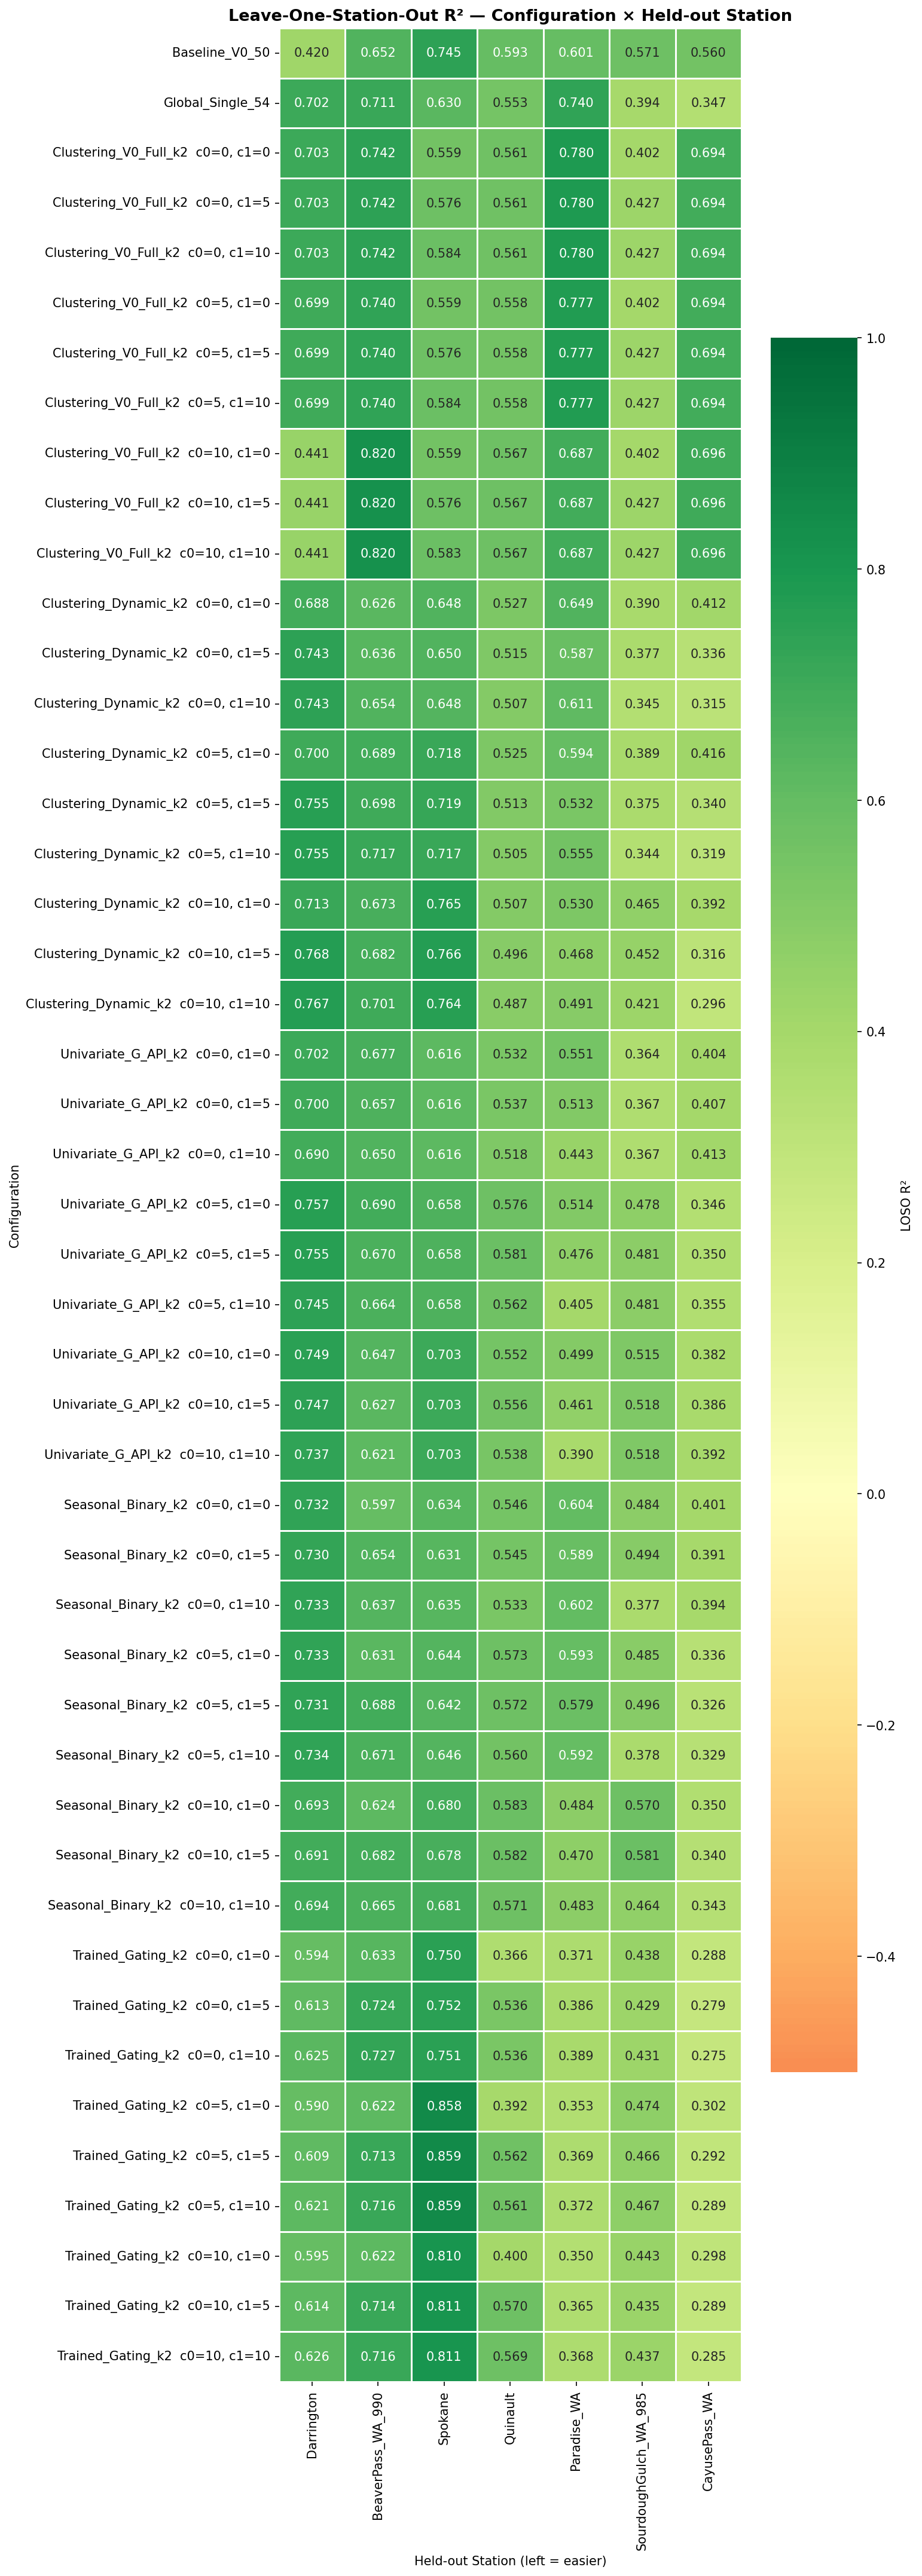

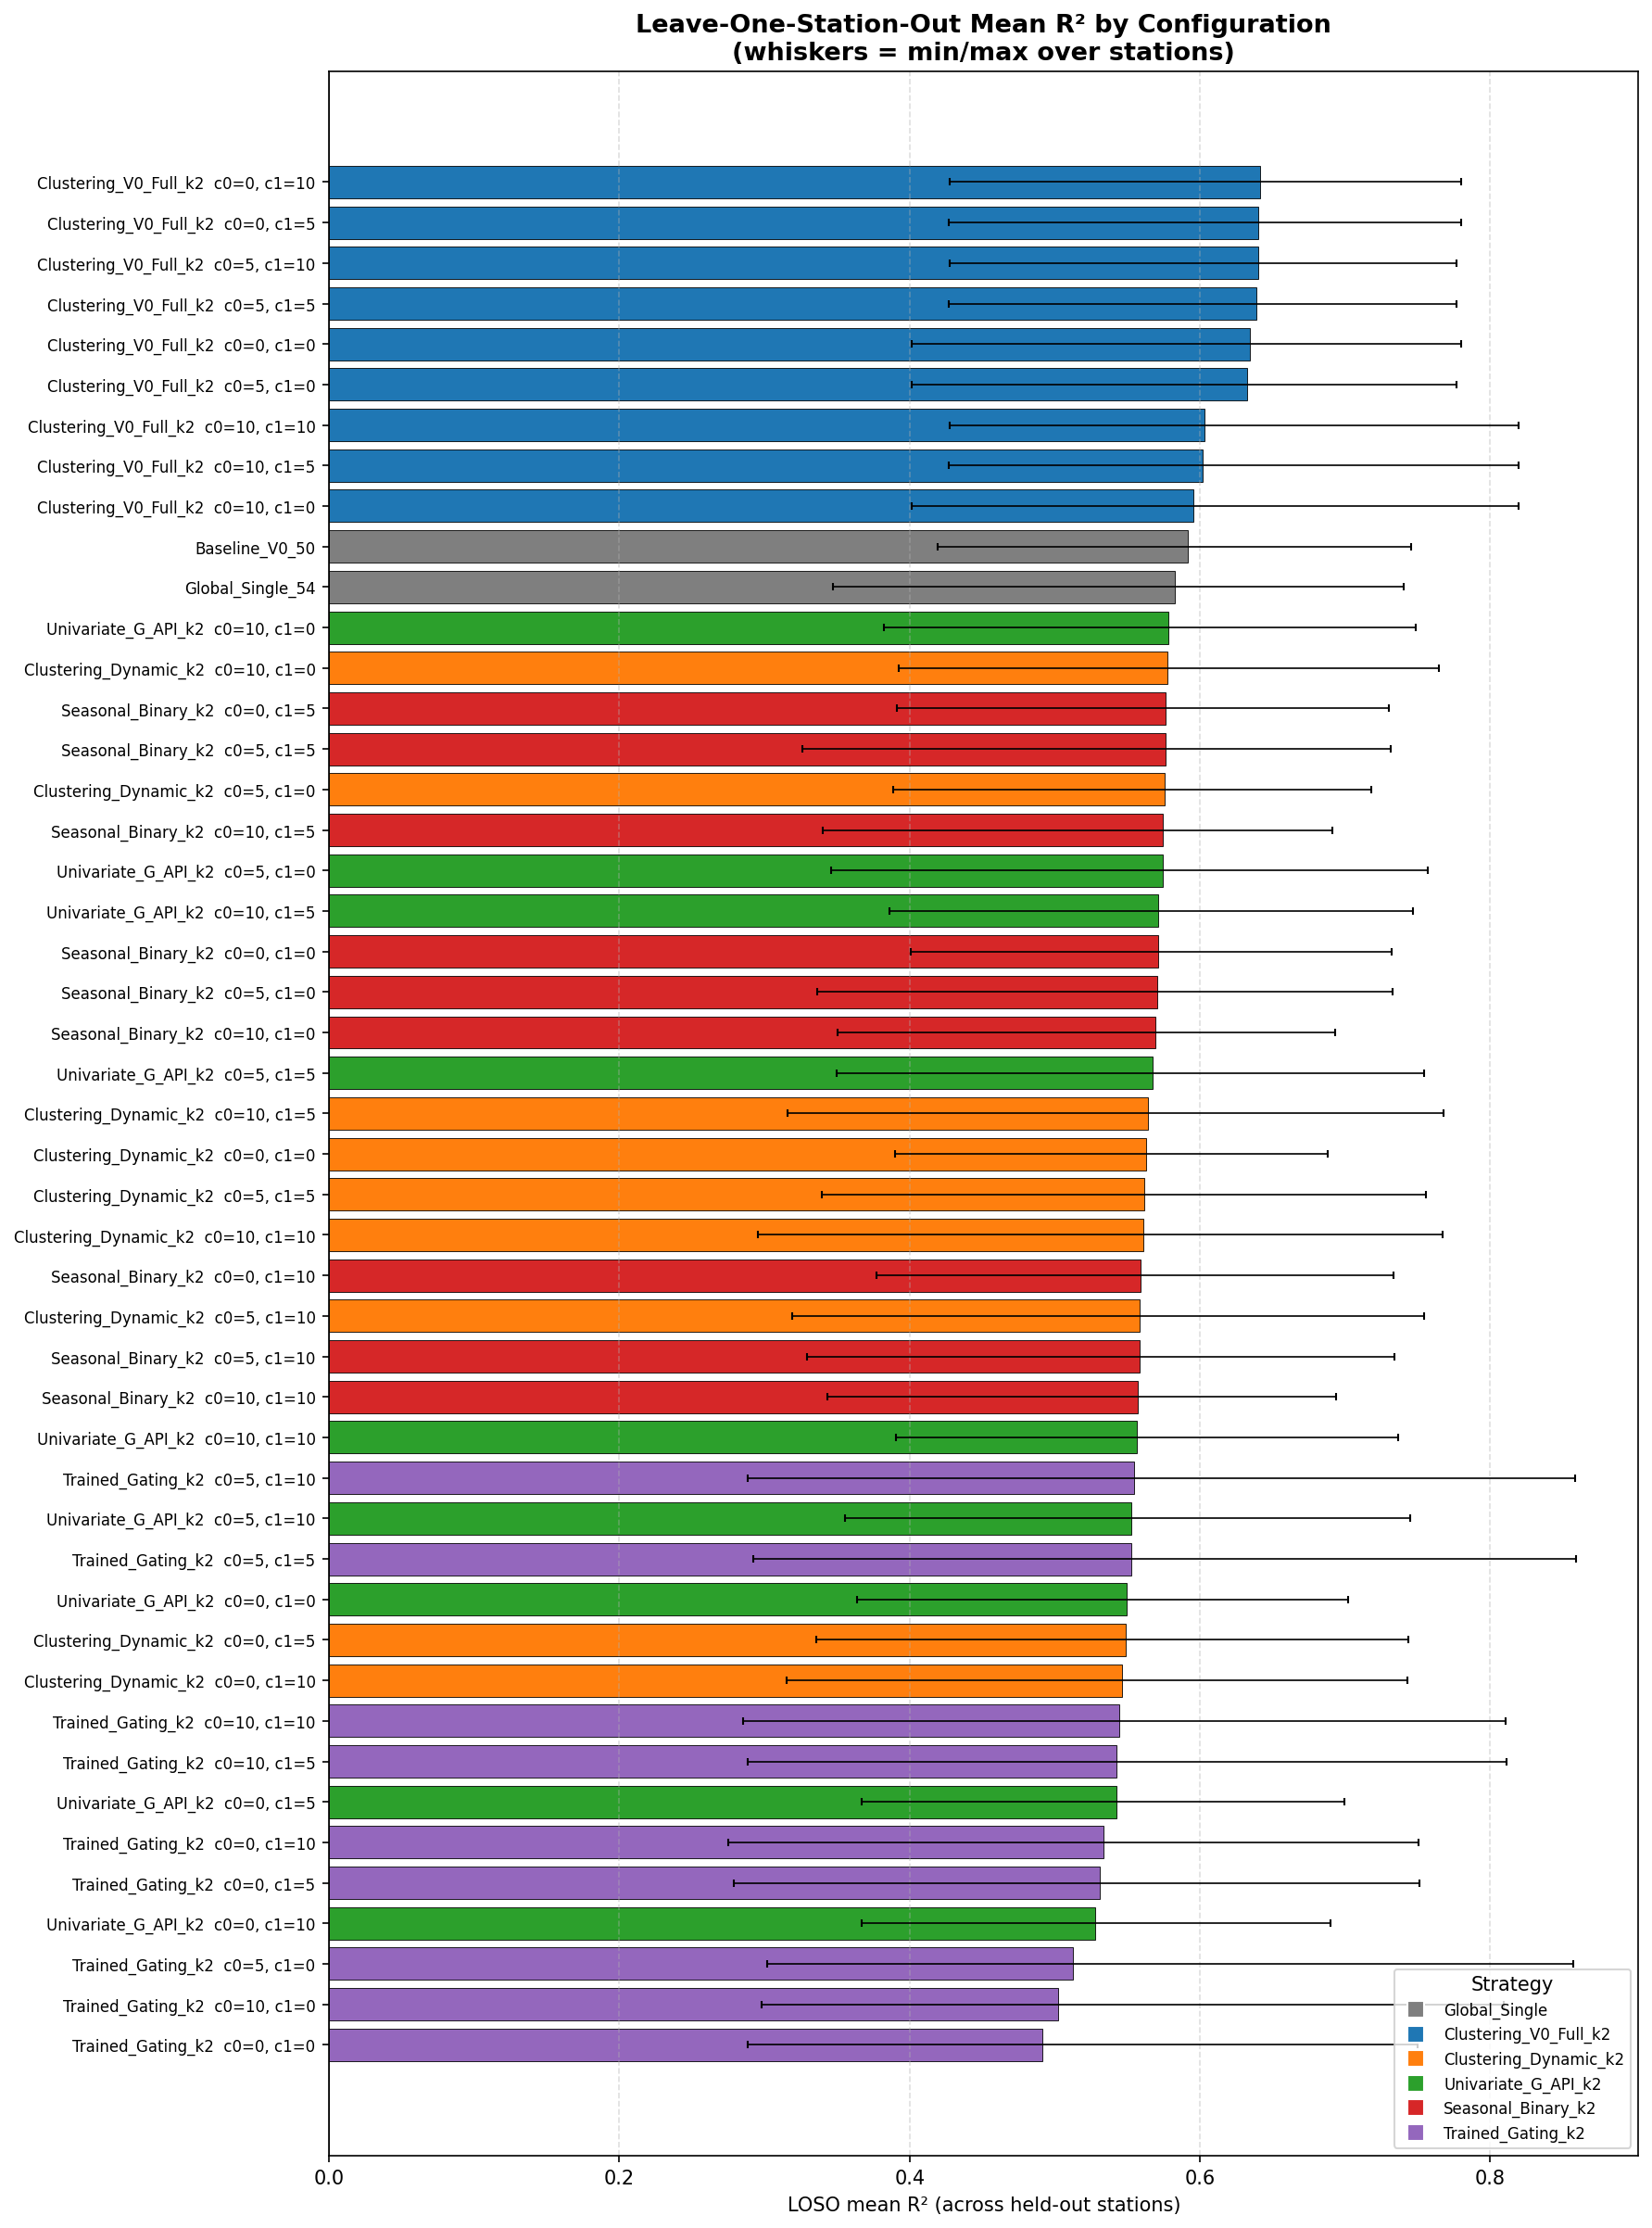

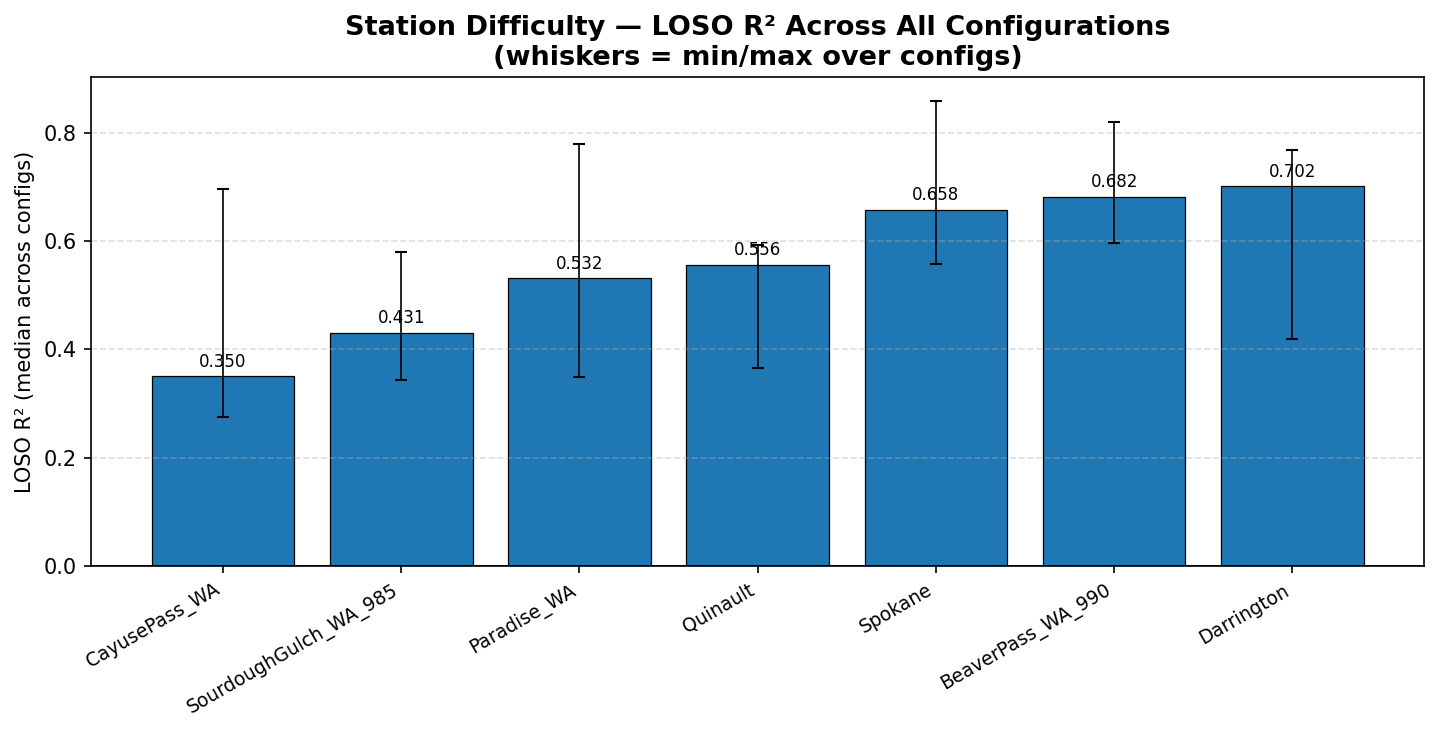

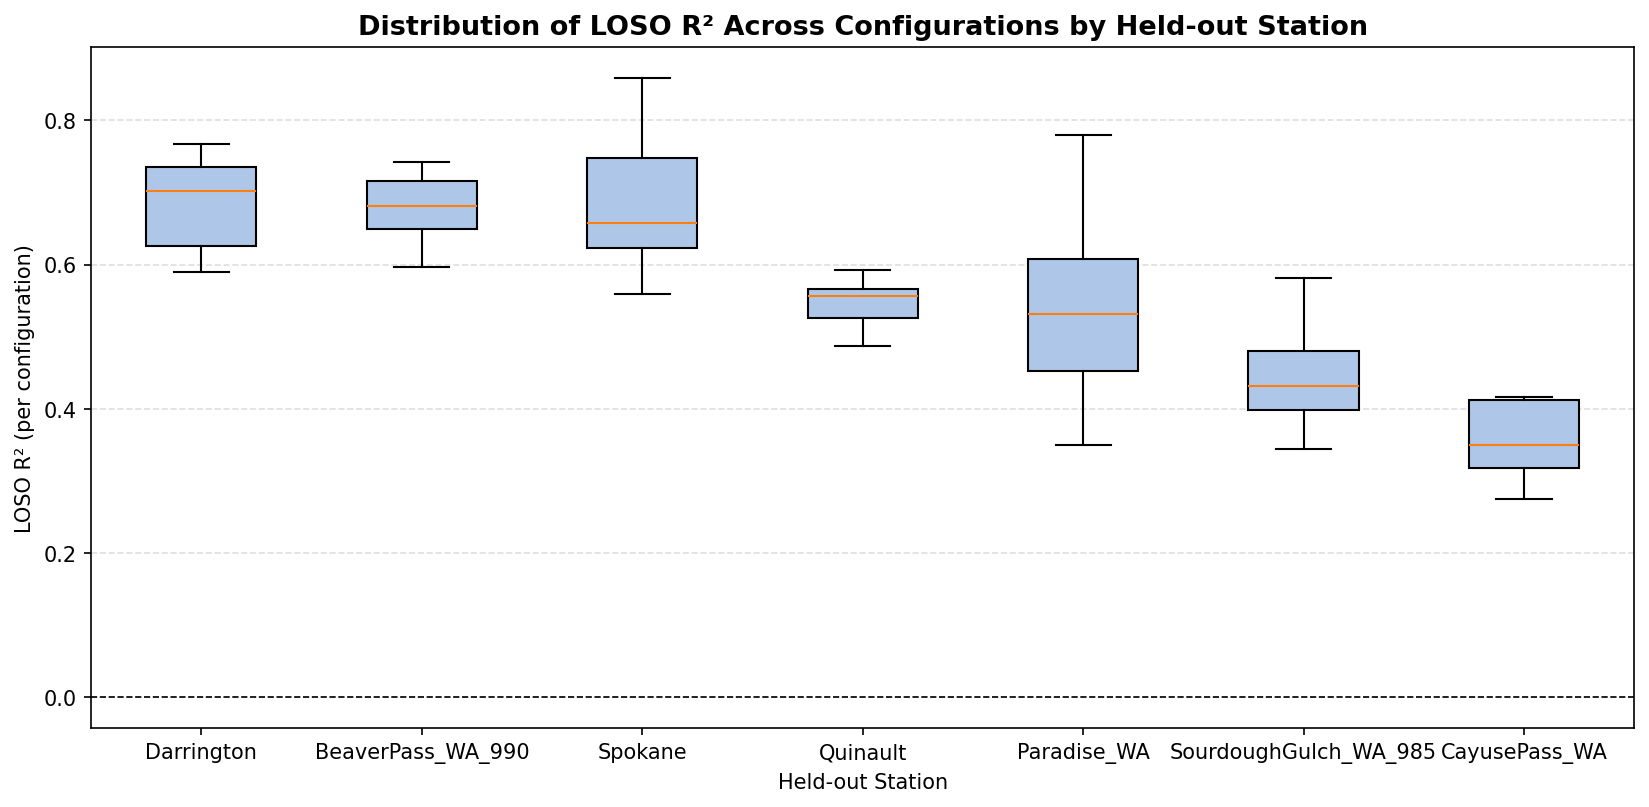

In [7]:
for fig in [
    "loso_r2_config_station_heatmap.png",
    "loso_r2_config_summary.png",
    "loso_station_difficulty.png",
    "loso_r2_station_boxplot.png",
]:
    display(Image(filename=str(EXP_DIR / fig)))

## Station Similarity & Clustering — Spatial-Generalization Hypothesis

**Hypothesis.** A station generalizes well spatially when the LOSO training set contains another station with *similar climate and geography* ("a twin"), and poorly when the station *stands out* from the rest. This section builds per-station feature vectors — WorldClim BioClim BIO1-19, geography, and soil texture from `data/splits/derived_8.4/station_static_features.csv`, plus observed climatology (mean/std of precip, LST, NDVI, SMAP, soil moisture over train+val) — then clusters the 7 stations (Ward + PCA) and tests the hypothesis by correlating per-station isolation metrics against two LOSO difficulty measures: the median R² over all 47 configurations and the per-station R² of the best spatial generalizer (the eval-1.1 winner). Implementation lives in `eval12/station_sim.py`; every number below is computed by this notebook.

In [8]:
import sys
import yaml

sys.path.insert(0, str(EXP_DIR.resolve()))
from eval12 import station_sim as ss

with open(EXP_DIR / "config.yaml") as f:
    _cfg = yaml.safe_load(f)
PROJECT_ROOT = Path("../../..").resolve()

feats = ss.build_station_features(PROJECT_ROOT, _cfg)
print(f"Feature sets: {len(ss.GEO_FEATURES)} geography, {len(ss.BIOCLIM_FEATURES)} BioClim, "
      f"{len(ss.SOIL_FEATURES)} soil, {len(ss.DYNAMIC_FEATURES)} observed-climatology "
      f"({len(ss.STATIC_FEATURES) + len(ss.DYNAMIC_FEATURES)} total).")
print(f"Land cover: {dict(feats.landcover)}")

diff = ss.load_difficulty(EXP_DIR)
profile = ss.station_profile_table(feats, {"median_r2": diff["median_r2"]})
print("\n### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)")
print(profile.to_markdown())

Feature sets: 6 geography, 19 BioClim, 4 soil, 10 observed-climatology (39 total).
Land cover: {'Spokane': 'Tree cover', 'Darrington': 'Tree cover', 'Quinault': 'Tree cover', 'SourdoughGulch_WA_985': 'Grassland', 'BeaverPass_WA_990': 'Tree cover', 'CayusePass_WA': 'Tree cover', 'Paradise_WA': 'Tree cover'}

### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)
| station_id            | landcover   |   latitude |   longitude |   J_elev_m |   J_slope_deg |   J_bio_bio01 |   J_bio_bio12 |   J_sand_wfrac_b0 |   J_clay_wfrac_b0 |   mean_precip_mm |   mean_LST_modis |   mean_F_NDVI |   mean_soil_moisture_5cm |   median_r2 |
|:----------------------|:------------|-----------:|------------:|-----------:|--------------:|--------------:|--------------:|------------------:|------------------:|-----------------:|-----------------:|--------------:|-------------------------:|------------:|
| Spokane               | Tree cover  |      47.42 |     -117.53 |        705 |          

### Pairwise station distance

Euclidean distance on the z-scored 39-feature vector (29 static + 10 observed climatology). `nn_dist` (1-NN) is the distance to the closest *other* station — a small value means the station has a climate/geography "twin" in the dataset.

In [9]:
X_std = ss.standardize(feats.combined)
dist = ss.pairwise_distance(X_std)
print("### Pairwise Euclidean distance (standardized static + observed features)")
print(dist.round(2).to_markdown())

### Pairwise Euclidean distance (standardized static + observed features)
| station_id            |   Spokane |   Darrington |   Quinault |   SourdoughGulch_WA_985 |   BeaverPass_WA_990 |   CayusePass_WA |   Paradise_WA |
|:----------------------|----------:|-------------:|-----------:|------------------------:|--------------------:|----------------:|--------------:|
| Spokane               |      0    |         9.57 |      12.85 |                    4.14 |               10.56 |           11.06 |         11.56 |
| Darrington            |      9.57 |         0    |       7.58 |                    9.39 |                8.14 |            8.64 |          8.92 |
| Quinault              |     12.85 |         7.58 |       0    |                   12.64 |               11.59 |           10.17 |          9.05 |
| SourdoughGulch_WA_985 |      4.14 |         9.39 |      12.64 |                    0    |                9.86 |           10.31 |         10.94 |
| BeaverPass_WA_990     |     10.56 | 

### Hierarchical clustering and PCA

Ward linkage on the same standardized features; flat cluster assignments at k = 2 and k = 3 (k = 2 mirrors the MoE routers' two-regime split). PCA gives a 2-D view of the station embedding.

In [10]:
Z = ss.ward_linkage(X_std)
order = ss.leaf_order(Z, list(X_std.index))
print("Dendrogram leaf order:", order)
for k in (2, 3):
    print(f"\n### Ward clusters (k={k})")
    cl = ss.cluster_labels(Z, k, list(X_std.index)).to_frame("cluster")
    cl["median_r2"] = diff["median_r2"]
    print(cl.to_markdown())
scores, ev, loadings = ss.pca_projection(X_std)
print(f"\nPCA explained variance: PC1 = {ev[0]:.1%}, PC2 = {ev[1]:.1%} (total {ev.sum():.1%})")

Dendrogram leaf order: ['Spokane', 'SourdoughGulch_WA_985', 'Darrington', 'Quinault', 'BeaverPass_WA_990', 'CayusePass_WA', 'Paradise_WA']

### Ward clusters (k=2)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.658365 |
| Darrington            |         2 |    0.701914 |
| Quinault              |         2 |    0.556385 |
| SourdoughGulch_WA_985 |         1 |    0.431192 |
| BeaverPass_WA_990     |         2 |    0.68179  |
| CayusePass_WA         |         2 |    0.35014  |
| Paradise_WA           |         2 |    0.531612 |

### Ward clusters (k=3)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.658365 |
| Darrington            |         2 |    0.701914 |
| Quinault              |         2 |    0.556385 |
| SourdoughGulch_WA_985 |         1 |    0.431192 |
| BeaverPass_WA_990     |      

In [11]:
iso = ss.isolation_scores(X_std)
tbl = iso.join(diff[["median_r2", "mean_r2", "winner_r2"]])
tbl = tbl.sort_values("median_r2", ascending=False)
print(f"Winner config used for `winner_r2`: {diff['winner_config'].iloc[0]}")
print("\n### Isolation metrics vs LOSO difficulty")
print(tbl.round(3).to_markdown())
print("\n### Spearman rank correlation (isolation × difficulty)")
print(ss.spearman_table(iso, diff).to_markdown(index=False))

Winner config used for `winner_r2`: Clustering_V0_Full_k2_c0_0_c1_10

### Isolation metrics vs LOSO difficulty
| station_id            |   nn_dist |   mean_dist |   centroid_dist |   median_r2 |   mean_r2 |   winner_r2 |
|:----------------------|----------:|------------:|----------------:|------------:|----------:|------------:|
| Darrington            |     7.58  |       8.705 |           5.134 |       0.702 |     0.677 |       0.703 |
| BeaverPass_WA_990     |     6.546 |       8.996 |           5.759 |       0.682 |     0.687 |       0.742 |
| Spokane               |     4.138 |       9.956 |           7.254 |       0.658 |     0.681 |       0.584 |
| Quinault              |     7.58  |      10.649 |           7.831 |       0.556 |     0.538 |       0.561 |
| Paradise_WA           |     2.23  |       8.331 |           5.343 |       0.532 |     0.546 |       0.78  |
| SourdoughGulch_WA_985 |     4.138 |       9.546 |           6.71  |       0.431 |     0.441 |       0.427 |
| CayuseP

In [12]:
# Sensitivity: static features only (geography + BioClim + soil; no target-derived
# observed climatology) — confirms the correlation pattern is not an artifact of
# including mean/std soil moisture in the feature vector.
X_static = ss.standardize(feats.static)
iso_static = ss.isolation_scores(X_static)
print("### Sensitivity — static features only (geography + BioClim + soil)")
print(ss.spearman_table(iso_static, diff).to_markdown(index=False))

### Sensitivity — static features only (geography + BioClim + soil)
| isolation_metric   | difficulty_metric   |   spearman_rho |   p_value |   n |
|:-------------------|:--------------------|---------------:|----------:|----:|
| nn_dist            | median_r2           |          0.771 |     0.042 |   7 |
| nn_dist            | mean_r2             |          0.606 |     0.149 |   7 |
| nn_dist            | winner_r2           |         -0.037 |     0.938 |   7 |
| mean_dist          | median_r2           |          0.286 |     0.535 |   7 |
| mean_dist          | mean_r2             |          0.25  |     0.589 |   7 |
| mean_dist          | winner_r2           |         -0.643 |     0.119 |   7 |
| centroid_dist      | median_r2           |         -0.071 |     0.879 |   7 |
| centroid_dist      | mean_r2             |          0.071 |     0.879 |   7 |
| centroid_dist      | winner_r2           |         -0.607 |     0.148 |   7 |


### Figures

Five figures summarize the station similarity structure and the hypothesis test: (1) pairwise similarity heatmap in dendrogram order, (2) Ward dendrogram with leaf colors by difficulty tier, (3) PCA embedding colored by median LOSO R² with the top feature loadings, (4) isolation-vs-difficulty scatter (1-NN / mean distance × median / winner-config R², Spearman ρ annotated), and (5) the standardized feature matrix showing which features make the hard stations extreme.

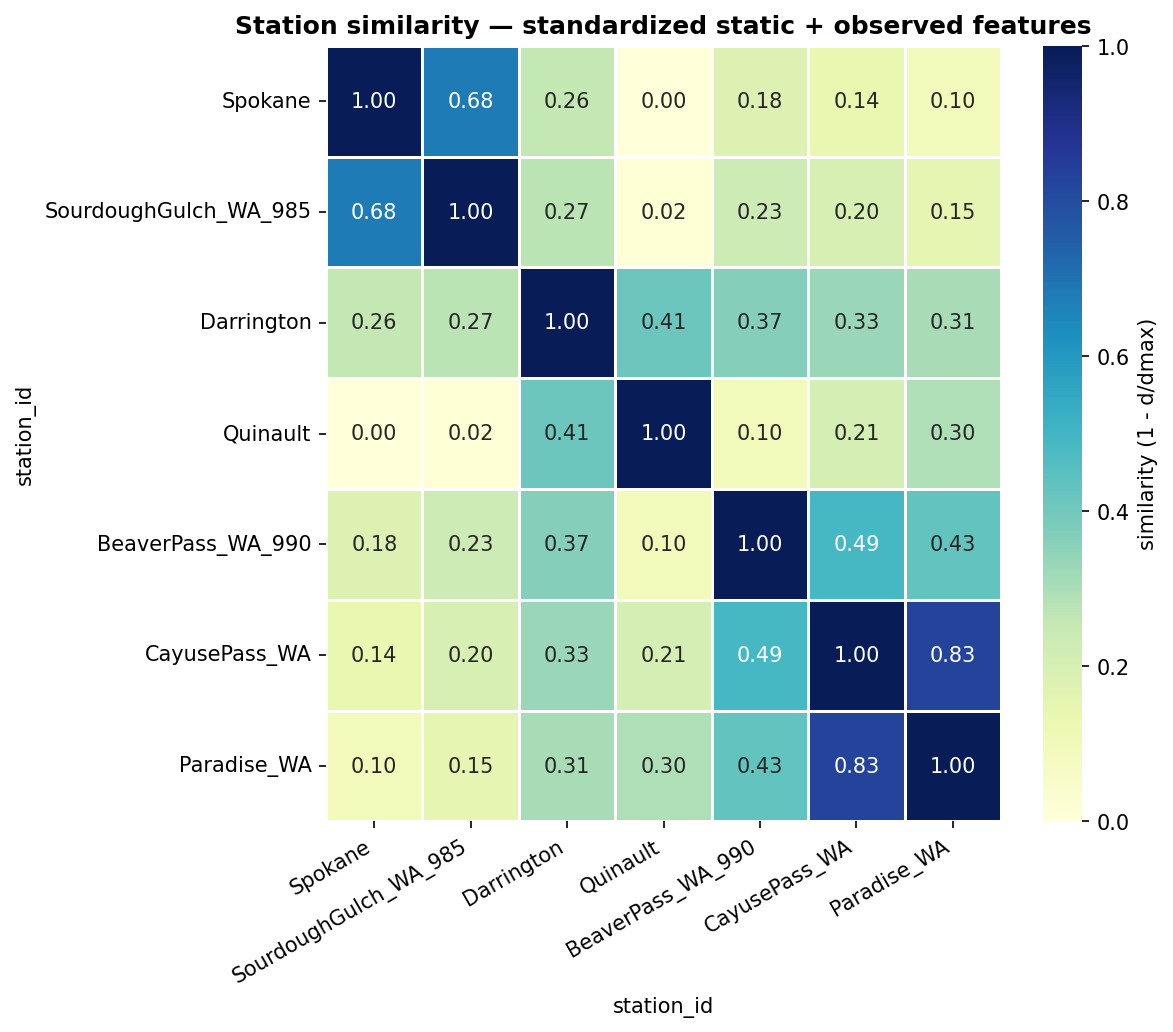

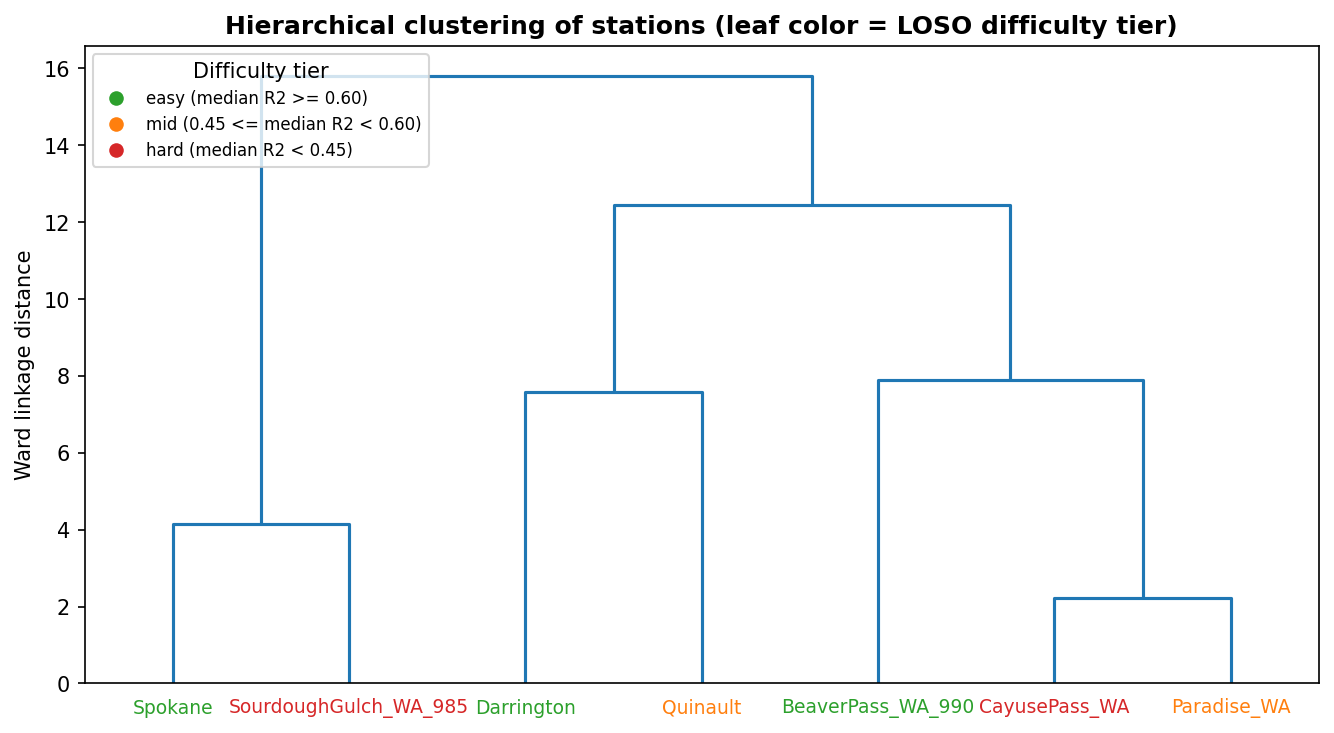

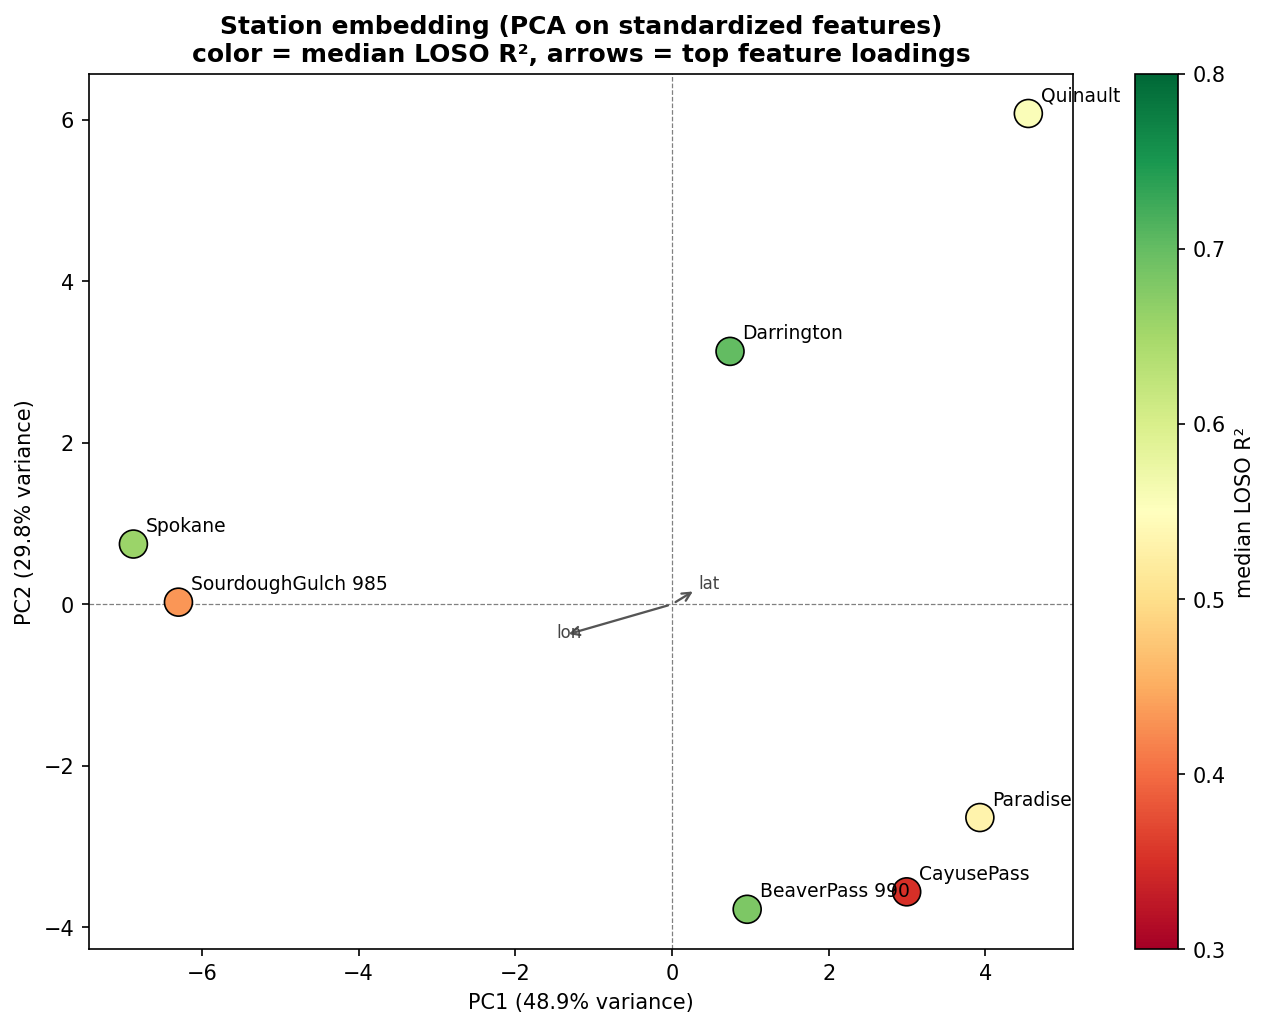

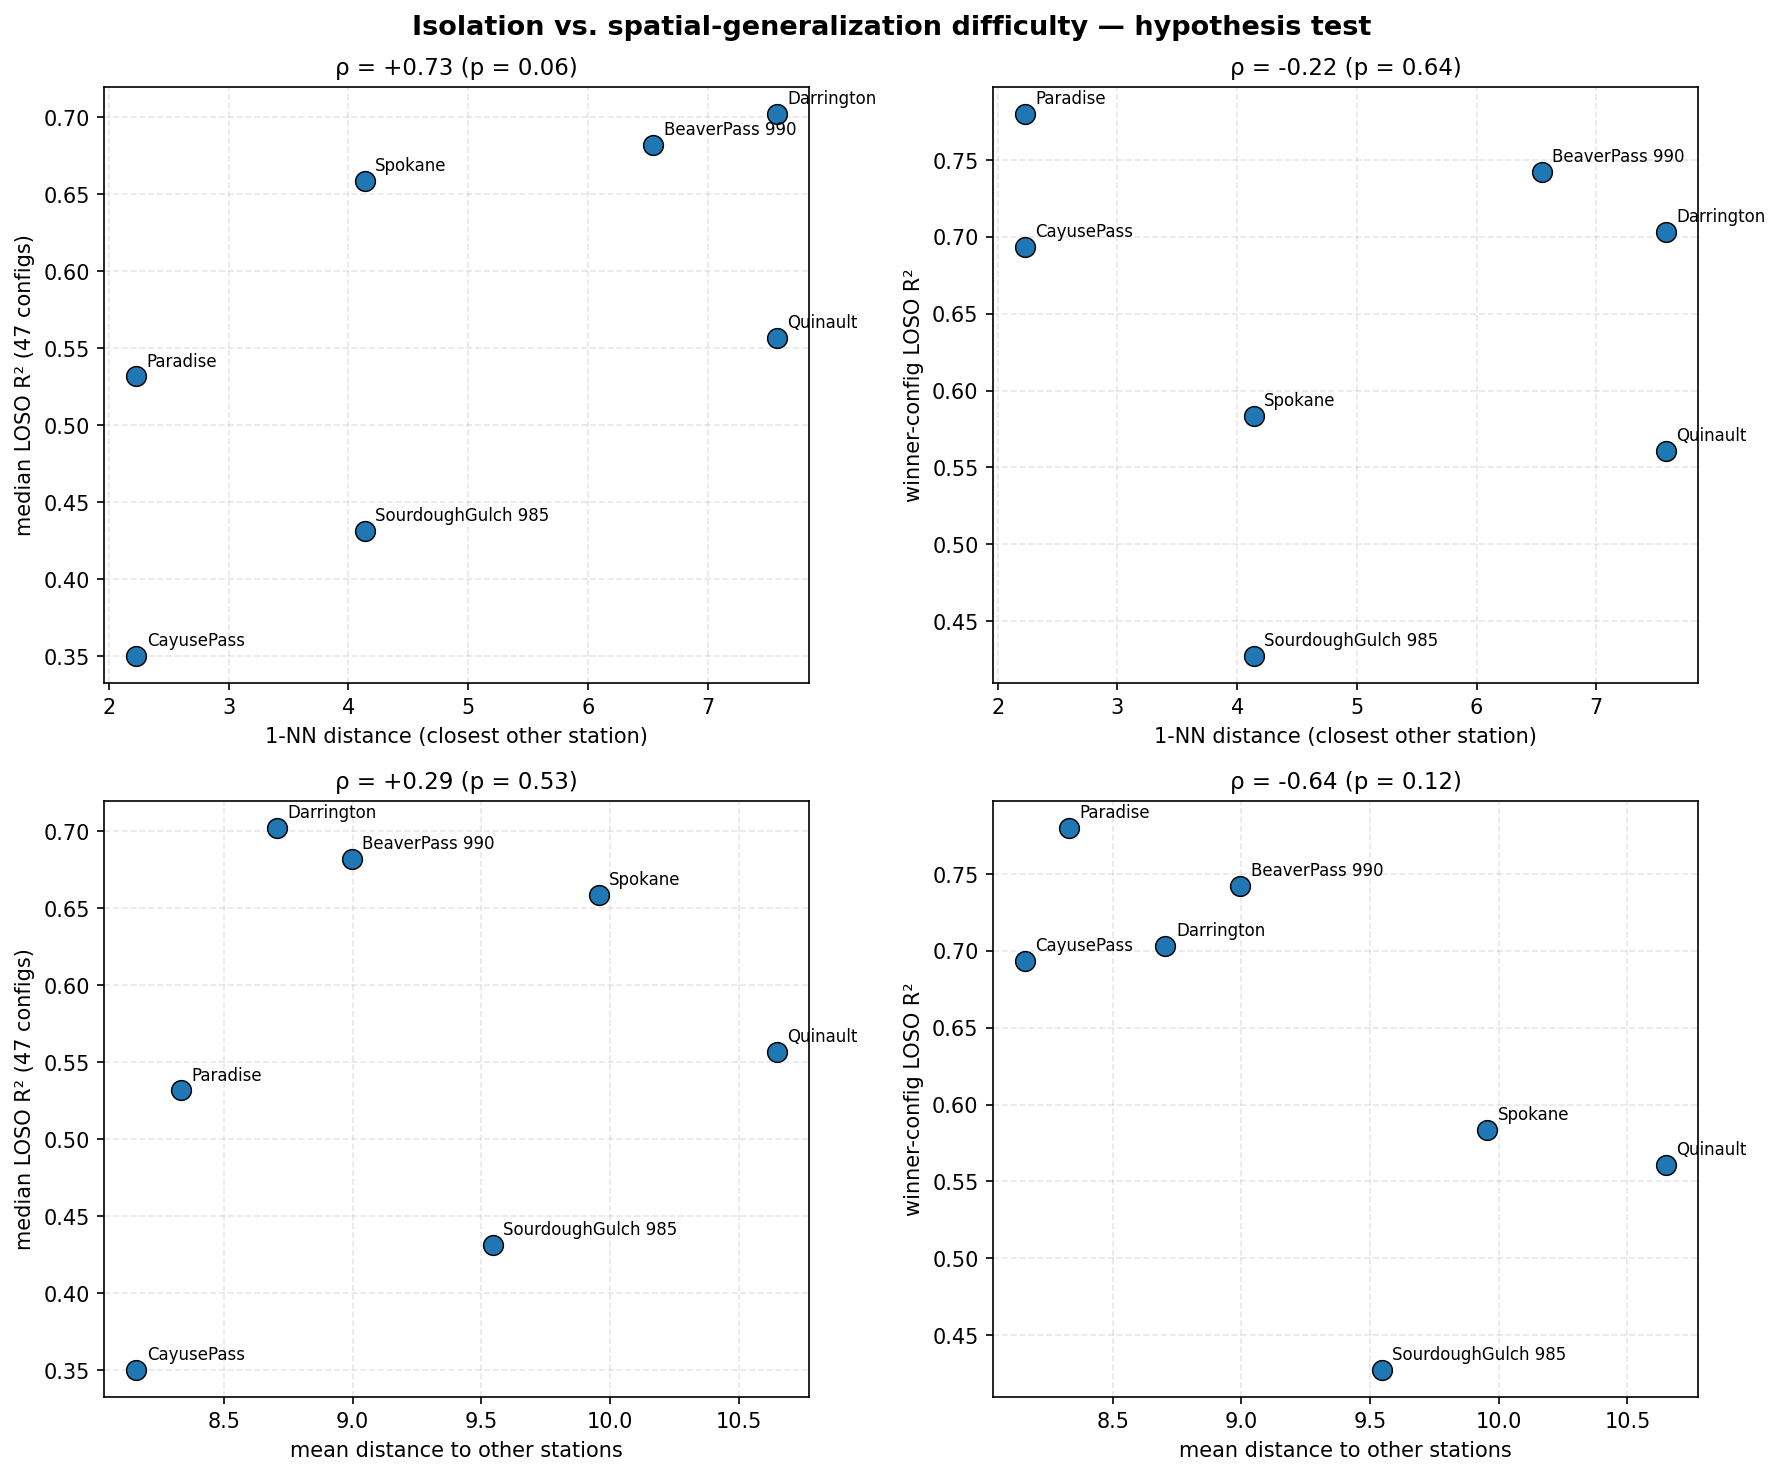

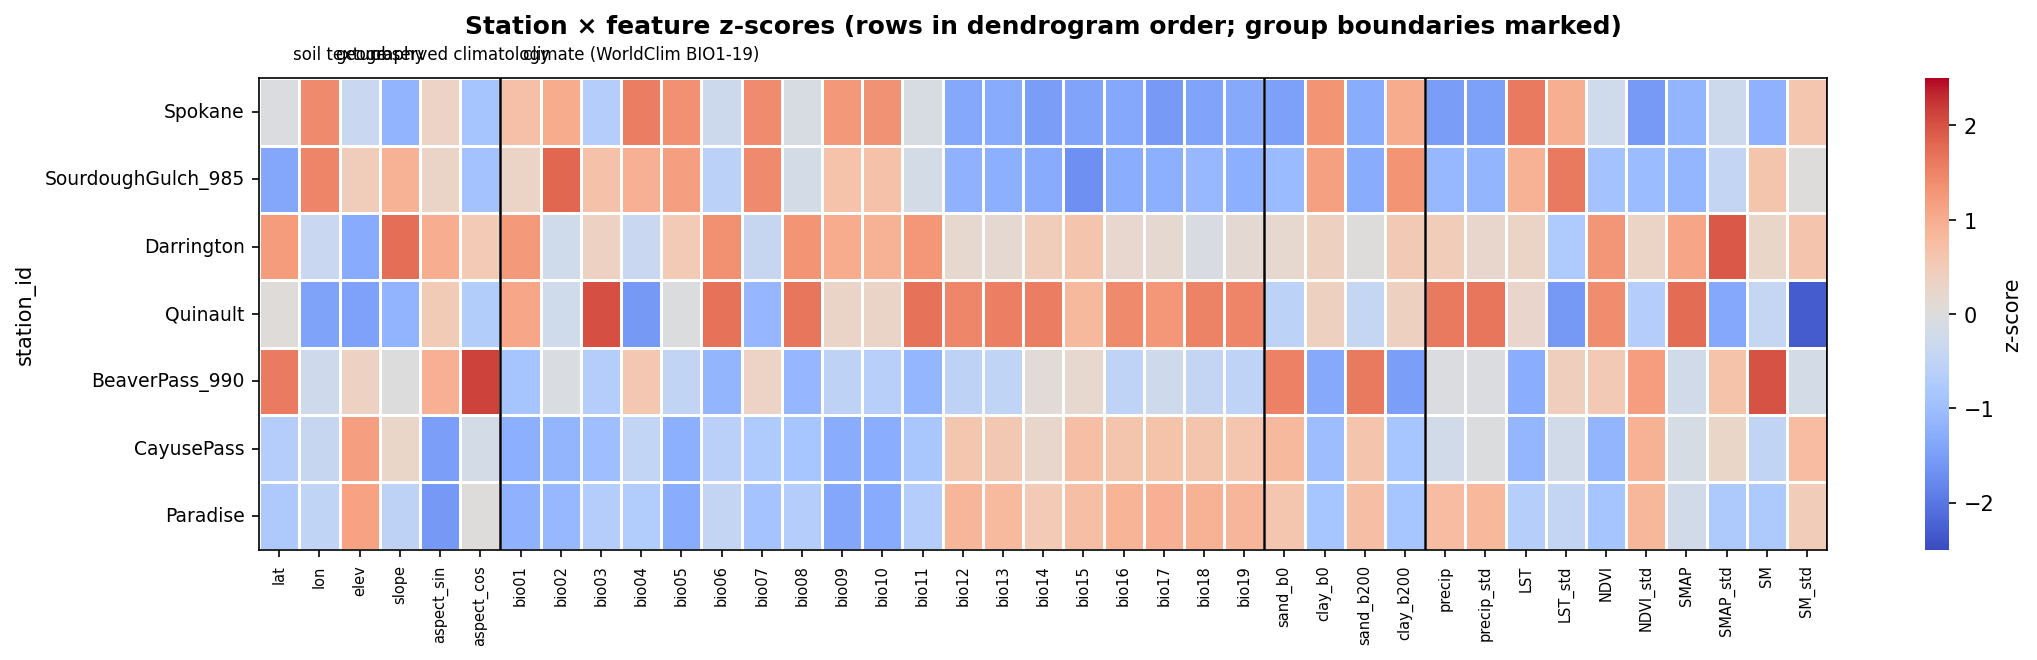

Saved 5 station-similarity figures to the experiment directory.


In [13]:
sim = ss.similarity_matrix(dist)
for fig_path in [
    ss.plot_similarity_heatmap(sim, order, EXP_DIR),
    ss.plot_dendrogram(Z, list(X_std.index), diff, EXP_DIR),
    ss.plot_pca_scatter(scores, ev, loadings, diff, EXP_DIR),
    ss.plot_isolation_vs_difficulty(iso, diff, EXP_DIR),
    ss.plot_feature_heatmap(X_std, order, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 5 station-similarity figures to the experiment directory.")

### Interpretation

**Similarity structure.** Ward clustering finds three natural pairs — {CayusePass, Paradise} (high-elevation Cascade sites, the tightest pair at distance 2.23), {Spokane, SourdoughGulch} (dry east-side, 4.14), and {Darrington, Quinault} (wet west-side, 7.58) — with BeaverPass joining the high-elevation group (k = 3). SourdoughGulch is the **only grassland** station (all others tree cover), i.e. the most unique by land cover.

**Hypothesis test.** The simple "twin → easy" story is **not supported** by the aggregate difficulty: 1-NN distance correlates *positively* with median LOSO R² (ρ = +0.73), i.e. the closest twins (CayusePass ↔ Paradise) are among the *hardest* stations on average. Under the best spatial generalizer the pattern flips toward the hypothesis — mean-distance isolation correlates *negatively* with winner-config R² (ρ = −0.64), and the unique grassland station SourdoughGulch is the hardest (0.43) under both measures — but none of these correlations is significant at n = 7.

**Joint reading.** Having a static-feature twin does not rescue generalization when the twin pair is jointly *extreme* (CayusePass/Paradise: highest elevation, coldest, snow-dominated); per-station difficulty is better explained by how far a station sits from the training-regime core and by its dynamic regime (SourdoughGulch's unique land cover / low vegetation) than by pairwise similarity alone. These results are descriptive for a 7-station sample and should be treated as hypotheses, not conclusions.

## Full-Training Baseline — Intrinsic vs. Generalization Difficulty

LOSO measures how well a model *generalizes* to a station it never saw during training. But a station can be hard for two different reasons: it is **intrinsically hard** (hard to fit even when its own rows are in the training set) or **generalization-limited** (easy to fit when trained on, but degrades when held out). To separate the two, every configuration was also trained **without LOSO** — router and experts fit on the full trainval (all 7 stations), exactly the `derived_8.4-eval-1.1` protocol — and evaluated per station on the test set (`run_full_baseline.py`, same 47 configurations as LOSO). Pooled R² per configuration replicates eval-1.1 to within machine precision, validating the baseline.

In [14]:
df_full_pcs = pd.read_csv(EXP_DIR / "full_per_config_station.csv")
df_full_summary = pd.read_csv(EXP_DIR / "full_config_summary.csv")
df_full_station = pd.read_csv(EXP_DIR / "full_station_summary.csv")

valid = df_full_summary.dropna(subset=["eval11_test_r2"])
print(f"Validation vs eval-1.1: {len(valid)} configs compared, "
      f"max |full_pooled_r2 − eval11_test_r2| = {valid['r2_diff'].max():.6f}")

full_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
             "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("\n### Station difficulty under FULL training (intrinsic; median over 47 configs)")
print(df_full_station[full_cols].to_markdown(index=False))

Validation vs eval-1.1: 47 configs compared, max |full_pooled_r2 − eval11_test_r2| = 0.000000

### Station difficulty under FULL training (intrinsic; median over 47 configs)
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |   min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|---------:|---------:|------------:|------------:|----------------:|
| Spokane               |          47 |          42159 |    0.937458 |  0.937761 | 0.0105326 | 0.915413 | 0.9533   |   0.0285551 |  0.00286124 |               0 |
| Darrington            |          47 |          46953 |    0.808516 |  0.81208  | 0.0124409 | 0.784731 | 0.834393 |   0.0404802 |  0.0229579  |               0 |
| CayusePass_WA         |          47 |          50807 |    0.752472 |  0.755779 | 0.030019  | 0.704006 | 0.807327 |   0.0589092 |  0.00859075 |               0 |
| Paradise_

### Full-training vs LOSO difficulty

Merging the per-station medians: `median_r2_full` (trained on all stations) vs `median_r2_loso` (station held out). `gap = full − loso` is the LOSO cost — a large positive gap means the station is **generalization-limited** (fine when trained on, degrades when held out); a gap near zero means it is **intrinsically hard** (hard both ways); a negative gap means it performs *better* under LOSO than full training (anomaly worth flagging).

In [15]:
cmp = df_full_station[["station", "median_r2", "mean_r2"]].merge(
    df_station[["station", "median_r2", "mean_r2"]],
    on="station", suffixes=("_full", "_loso"),
)
cmp["gap_median"] = cmp["median_r2_full"] - cmp["median_r2_loso"]
cmp["gap_mean"] = cmp["mean_r2_full"] - cmp["mean_r2_loso"]
cmp = cmp.sort_values("median_r2_loso", ascending=False)
cols = ["station", "median_r2_full", "median_r2_loso", "gap_median",
        "mean_r2_full", "mean_r2_loso", "gap_mean"]
print("### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)")
print(cmp[cols].round(3).to_markdown(index=False))


### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)
| station               |   median_r2_full |   median_r2_loso |   gap_median |   mean_r2_full |   mean_r2_loso |   gap_mean |
|:----------------------|-----------------:|-----------------:|-------------:|---------------:|---------------:|-----------:|
| Darrington            |            0.809 |            0.702 |        0.107 |          0.812 |          0.677 |      0.135 |
| BeaverPass_WA_990     |            0.478 |            0.682 |       -0.203 |          0.481 |          0.687 |     -0.206 |
| Spokane               |            0.937 |            0.658 |        0.279 |          0.938 |          0.681 |      0.257 |
| Quinault              |            0.677 |            0.556 |        0.121 |          0.676 |          0.538 |      0.138 |
| Paradise_WA           |            0.738 |            0.532 |        0.206 |          0.741 |          0.546 |      0.195 |
| SourdoughGulch_WA_985 |            0.4

In [16]:
from scipy.stats import spearmanr
rho, p = spearmanr(cmp["median_r2_full"], cmp["median_r2_loso"])
print(f"Spearman(full median R², LOSO median R²) = {rho:+.3f} (p = {p:.3f}, n = {len(cmp)})")
print("High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.")

Spearman(full median R², LOSO median R²) = +0.286 (p = 0.535, n = 7)
High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.


### Figures

Three figures compare the two difficulty measures: (1) scatter of per-station median R² (full vs LOSO) with the identity line, (2) paired bars per station sorted by LOSO difficulty, and (3) per-station boxplot of the per-configuration LOSO cost (full-training R² − LOSO R²).

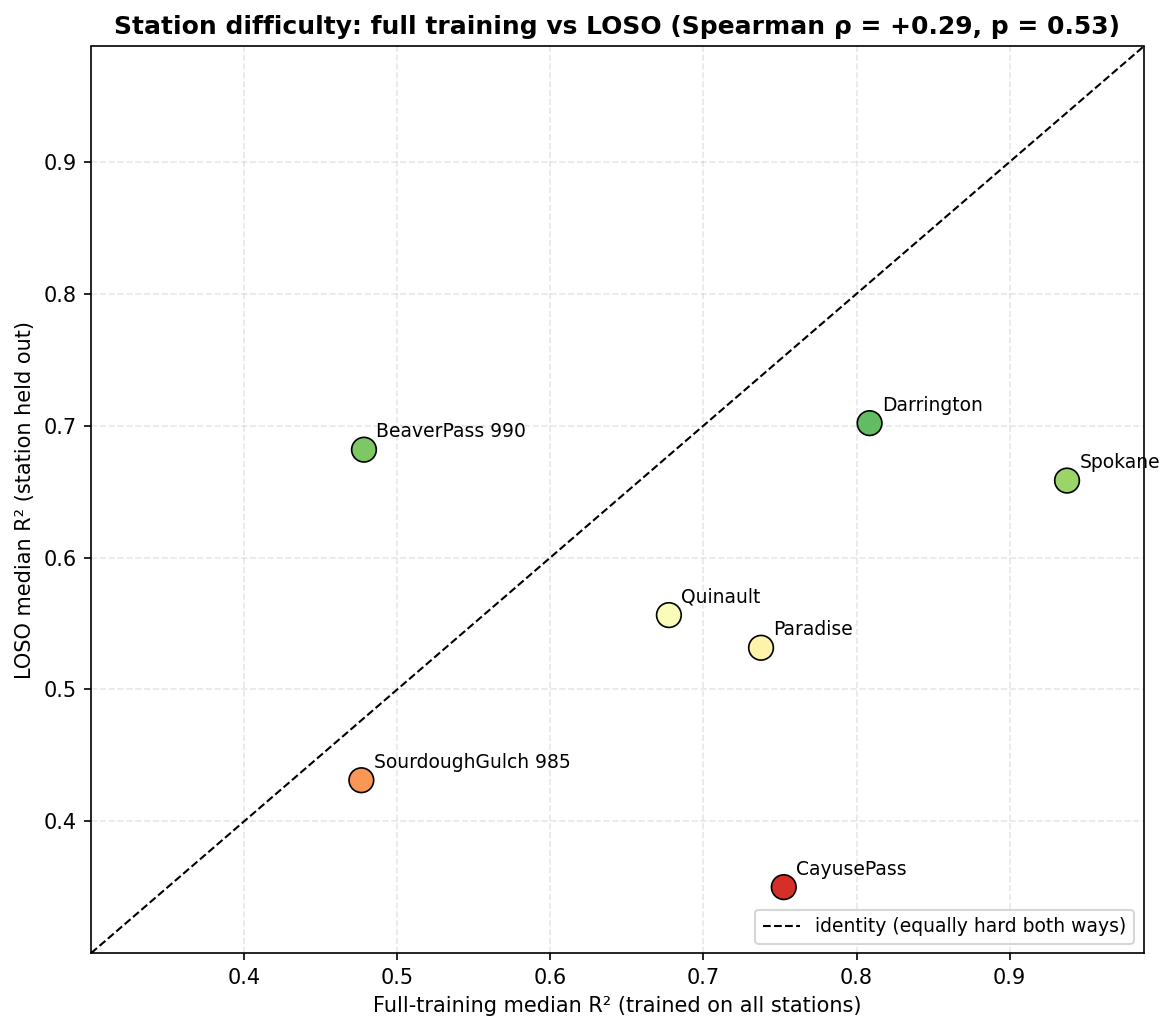

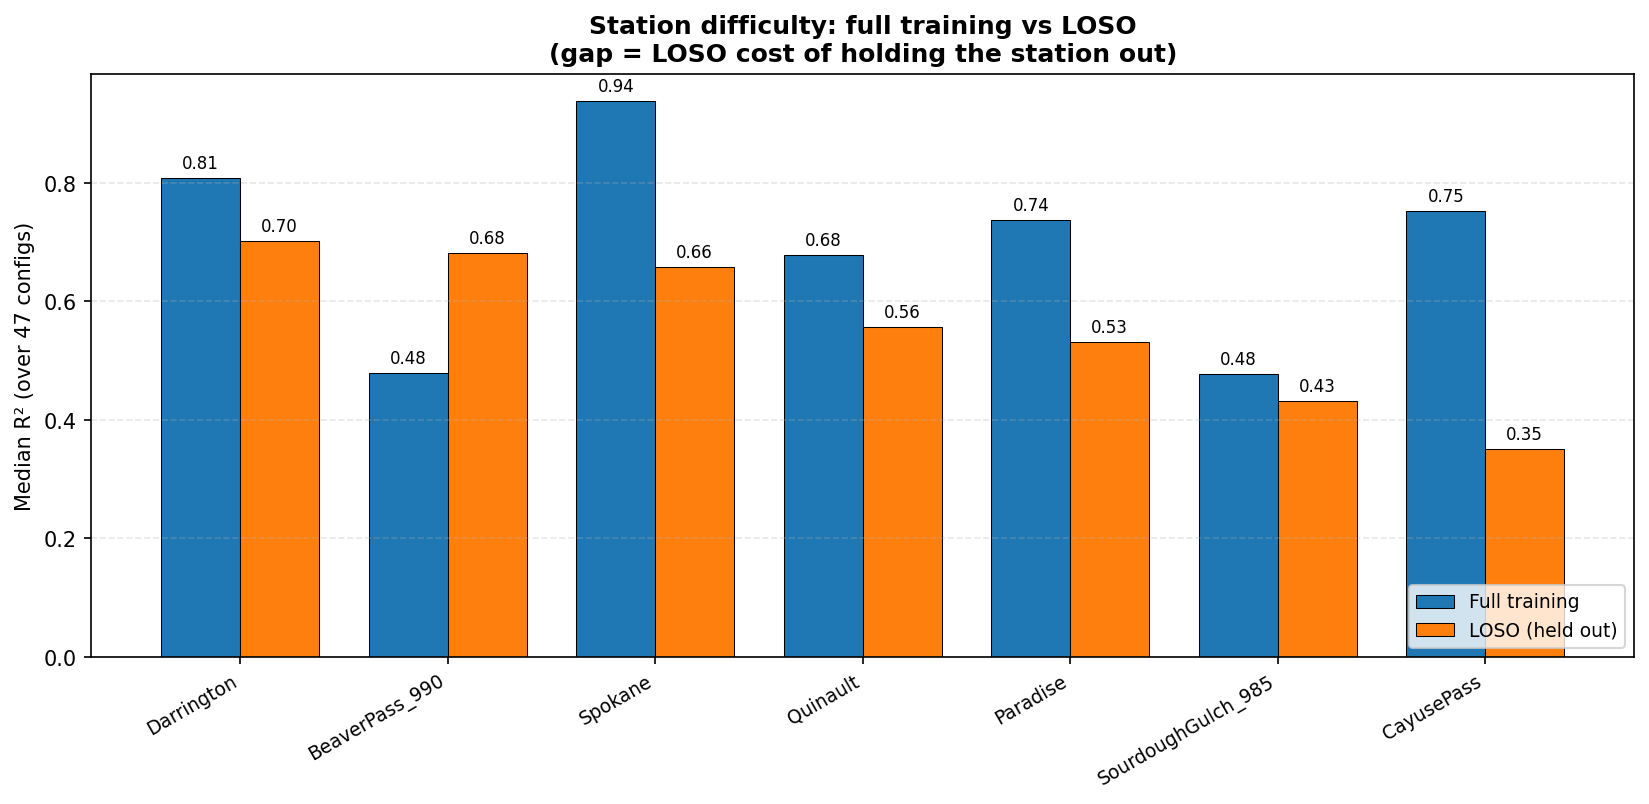

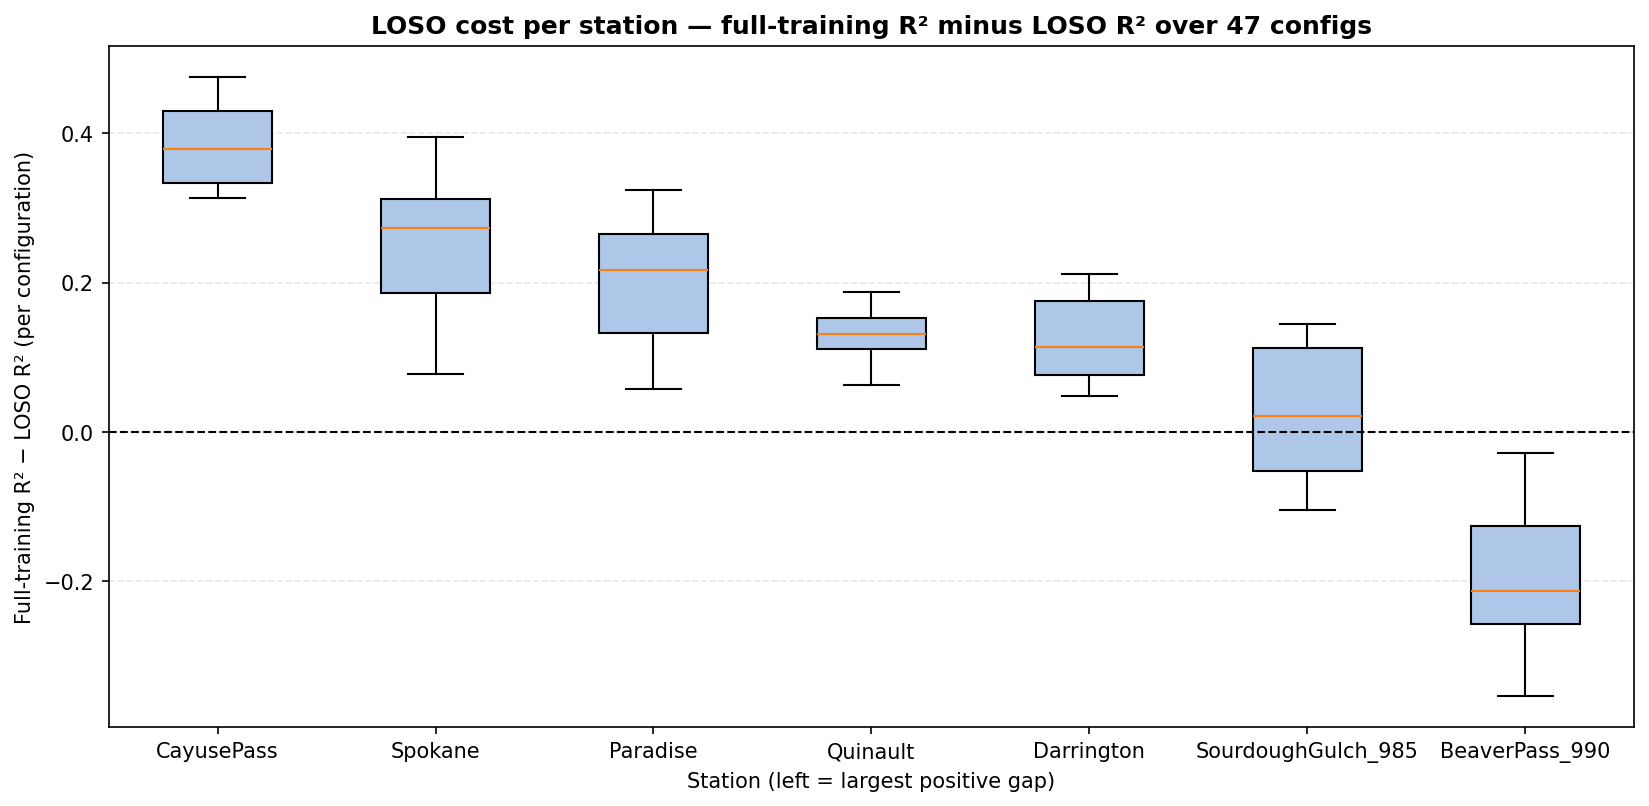

Saved 3 full-baseline comparison figures.


In [17]:
from eval12.plots import plot_full_vs_loso_scatter, plot_full_vs_loso_bars, plot_loso_gap_boxplot

cmp_plot = cmp.rename(columns={"median_r2_full": "full_median_r2", "median_r2_loso": "loso_median_r2"})
for fig_path in [
    plot_full_vs_loso_scatter(cmp_plot, EXP_DIR),
    plot_full_vs_loso_bars(cmp_plot, EXP_DIR),
    plot_loso_gap_boxplot(df_full_pcs, df_pcs, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 3 full-baseline comparison figures.")

### Interpretation

**Replication.** All 47 configurations reproduce eval-1.1's pooled test R² exactly (max |diff| = 0.000000), so the full-training baseline is a faithful replica of 1.1 — LOSO is a true addition, not a replacement.

**Are LOSO-hard stations also hard under full training? Only weakly.** Spearman(full median R², LOSO median R²) = +0.286 (p = 0.535, n = 7): the station-difficulty rank order changes substantially between the two protocols, so LOSO difficulty is mostly *generalization-specific* rather than intrinsic.

**The two hardest LOSO stations split cleanly:**
- **CayusePass** is **generalization-limited**: easy when trained on (full median 0.752) yet the hardest under LOSO (0.350) — gap +0.40. Its snow-dominated high-elevation regime is fit well when its own rows are present, but the other stations cannot supply that regime when it is held out.
- **SourdoughGulch** is **intrinsically hard**: 0.477 full vs 0.431 LOSO — gap only +0.05. Even with its own rows in training it remains the joint-hardest station (with BeaverPass), consistent with its uniqueness (the only grassland station).

**BeaverPass anomaly.** BeaverPass is *harder* under full training (median 0.478) than under LOSO (0.682), gap −0.20 — the only station that does *better* when held out. It has the fewest test rows (626) and its regime overlaps few training rows, so including it in full training appears to hurt rather than help.

**Bottom line.** Station difficulty is not one-dimensional: LOSO difficulty measures *transfer*, full-training difficulty measures *fitability*. Only SourdoughGulch is hard on both axes (intrinsically hard *and* hard to generalize to); CayusePass's difficulty is almost entirely a transfer phenomenon.
